In [3]:
import pandas as pd

data = pd.read_csv("../data/processed_data.csv")

print(data.shape)


# One Hot Encoding
data = pd.get_dummies(data,columns=["Type", "Store", "IsHoliday"],drop_first=True)

X = data.drop("Weekly_Sales", axis=1)
y = data["Weekly_Sales"]

# Train Test Split


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


# Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

model = RandomForestRegressor(random_state=42)

params = {
    "n_estimators": [50, 100],
    "max_depth": [10,None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Score:")
print(random_search.best_score_)

(421570, 18)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  11.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  10.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  10.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  21.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  21.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  21.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  21.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_esti

In [4]:
import joblib

best_rf = random_search.best_estimator_

joblib.dump(best_rf, "../models/best_random_forest.pkl")

print("Random Forest model saved!")

y_pred = best_rf.predict(X_test)
print("Predict sales")
print(y_pred[:10])

Random Forest model saved!
Predict sales
[18373.16652595 29443.61092264  4416.53771242  5920.06883714
  5524.7036954   6217.08528881 13018.32005905  6201.20928159
  8312.77576861 13407.31798738]


In [5]:
comparsion = pd.DataFrame({"actual_sales" : y_test.values,"predicted_sales" :y_pred })
print(comparsion.head(10))

   actual_sales  predicted_sales
0      50932.42     18373.166526
1       3196.12     29443.610923
2      10125.03      4416.537712
3       3311.26      5920.068837
4       6335.65      5524.703695
5       8971.23      6217.085289
6       1575.35     13018.320059
7      17308.45      6201.209282
8       5763.39      8312.775769
9      17034.57     13407.317987


In [6]:
from sklearn.metrics import  mean_squared_error,mean_absolute_error,r2_score
import numpy as np

r_mae = mean_absolute_error(y_test,y_pred)
r_mse = mean_squared_error(y_test,y_pred)
r_r2 =  r2_score(y_test ,y_pred)

print("MSE" , r_mse)
print("MAE" , r_mae)
print("R2_score",r_r2)

MSE 225985700.9710594
MAE 9253.410134968528
R2_score 0.5666380219464405


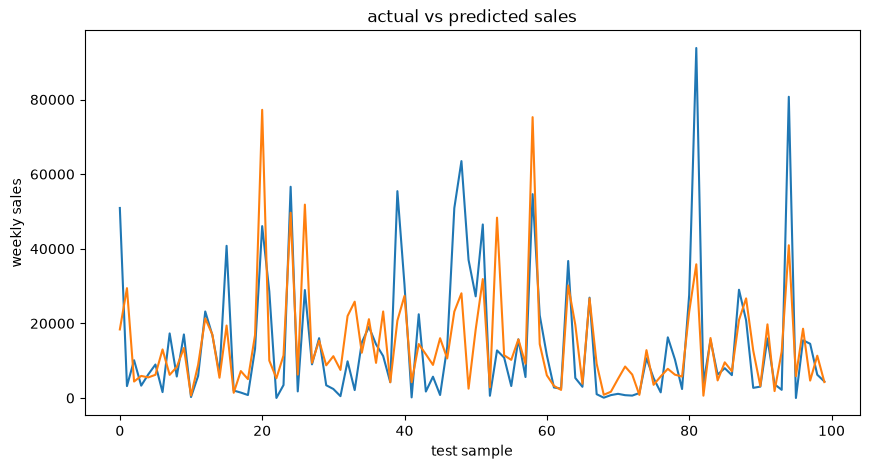

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100] , label = "actual sales")
plt.plot(y_pred[:100], label ="predicted sales")

plt.xlabel("test sample")
plt.ylabel("weekly sales")
plt.title("actual vs predicted sales")

plt.show()